In [1]:
import numpy as np
from datetime import datetime 

from typing import List, Set

import matplotlib.pyplot as plt
import xarray as xr
import rioxarray as rio
import seaborn as sns
sns.set_theme()
import pandas as pd
pd.set_option('display.precision', 2)

from pathlib import Path

import math
import gc

# Looking at short baseline flights over my study areas

I'm expecting three flights from RMNP and six flights from SLC. 

RMNP were all 7 day baselines while SLC had between 6 and 8 day baselines. 

In [57]:
data_dir = '/bsuhome/julialober/scratch/coherence_data/'
slc = xr.open_zarr(data_dir + 'stacks/slc_box_swe')

t1_str = slc["pair"].str[:6]
t2_str = slc["pair"].str[7:]
# print(t1_str)
t1_formatted = "20" + t1_str.str[:2] + "-" + t1_str.str[2:4] + "-" + t1_str.str[4:]
t2_formatted = "20" + t2_str.str[:2] + "-" + t2_str.str[2:4] + "-" + t2_str.str[4:]
t1_dt = t1_formatted.astype("datetime64[s]")
t2_dt = t2_formatted.astype("datetime64[s]")
# print(t1_dt[0], t2_dt[0])
days_elapsed = (t2_dt - t1_dt) / np.timedelta64(1, "D")
# print(days_elapsed[0])
slc["temp_baseline"] = days_elapsed
slc = slc.sel(pair=(days_elapsed <= 8))

rmnp = xr.open_zarr(data_dir + 'stacks/rmnp_box_swe')

t1_str = rmnp["pair"].str[:6]
t2_str = rmnp["pair"].str[7:]
# print(t1_str)
t1_formatted = "20" + t1_str.str[:2] + "-" + t1_str.str[2:4] + "-" + t1_str.str[4:]
t2_formatted = "20" + t2_str.str[:2] + "-" + t2_str.str[2:4] + "-" + t2_str.str[4:]
t1_dt = t1_formatted.astype("datetime64[s]")
t2_dt = t2_formatted.astype("datetime64[s]")
# print(t1_dt[0], t2_dt[0])
days_elapsed = (t2_dt - t1_dt) / np.timedelta64(1, "D")
# print(days_elapsed[0])
rmnp["temp_baseline"] = days_elapsed
rmnp = rmnp.sel(pair=(days_elapsed <= 8))

print(f"RMNP number of pairs < 8 days: {len(rmnp['pair'])}")
for p in rmnp['pair'].values: 
    print(f"{p}: {rmnp.sel(pair=p)['temp_baseline'].values}")
print(f"SLC number of pairs < 8 days: {len(slc['pair'])}")
for p in slc['pair'].values: 
    print(f"{p}: {slc.sel(pair=p)['temp_baseline'].values}")

RMNP number of pairs < 8 days: 3
200212_200219: 7.0
210127_210203: 7.0
210303_210310: 7.0
SLC number of pairs < 8 days: 6
200213_200221: 8.0
210203_210210: 7.0
210223_210303: 8.0
210303_210310: 7.0
210310_210316: 6.0
210316_210322: 6.0


In [58]:
inc_cutoff = 80
canopy_cutoff = 30
elev_quant = 60

In [59]:
def filter_data(data) : 
    single_year_pairs = [
        p for p in data.coords['pair'].values 
        if p[:2] == p[7:9]
    ]

    print(f'Filtering for {len(single_year_pairs)} single-year pairs.')
    data = data.sel(pair=single_year_pairs)

    print(f'Trimming to DEM.')
    data = data.where(data['elevation'].notnull())

    print(f'Filtering inc angle > {inc_cutoff}, canopy cover > {canopy_cutoff}, elev top {elev_quant}%.')
    condition = (data['incidence_angle'] < inc_cutoff) & \
                (data['canopy_2019'] < canopy_cutoff) & \
                (data['elevation'] > data['elevation'].quantile((100-elev_quant)/100))

    data = data.where(condition)

    return data

In [60]:
rmnp_good = filter_data(rmnp)
slc_good = filter_data(slc)

Filtering for 3 single-year pairs.
Trimming to DEM.
Filtering inc angle > 80, canopy cover > 30, elev top 60%.
Filtering for 6 single-year pairs.
Trimming to DEM.
Filtering inc angle > 80, canopy cover > 30, elev top 60%.


In [61]:
xpol_cutoff = 0.9 
to_filter = rmnp_good 

In [62]:
def filter_and_plot_pairs(
    dataset: xr.Dataset, 
    coh_dir: Path, 
    cutoff: float
) -> xr.Dataset:
    """
    Pre-loads cross-pol coherences, applies a cutoff mask to reference and secondary
    flights, plots a 3-panel figure per pair, and returns the filtered dataset.
    
    Args:
        dataset: The target InSAR xarray.Dataset (e.g., rmnp_good).
        coh_dir: Pathlib object pointing to the directory of cross-pol tif files.
        cutoff: The cross-pol coherence threshold to apply to the mask.
        
    Returns:
        A fully masked xarray.Dataset concatenated back along the 'pair' dimension.
    """
    
    # 1. Extract unique dates to avoid redundant loading
    all_pairs: List[str] = dataset['pair'].values.tolist()
    unique_dates: Set[str] = set()
    for pair_name in all_pairs:
        # Utilizing character slicing as determined in our previous session
        unique_dates.add(pair_name[:6])  
        unique_dates.add(pair_name[7:13]) 

    # print(unique_dates)
        
    # 2. Pre-load all unique cross-pol rasters into a single datacube
    xpol_list: List[xr.DataArray] = []
    valid_dates: List[str] = []
    
    
    for date_str in sorted(list(unique_dates)):
        file_path_list = list(coh_dir.glob(f"*{date_str}*_crosspol_coh.tif"))
        # print(file_path_list)
        
        try:
            # Enforce API safety / File loader robustness
            if not file_path_list:
                raise FileNotFoundError(f"Missing cross-pol raster for date: {date_str}")
            
            # Squeeze band, assign the date as a coordinate, and append
            da = rio.open_rasterio(file_path_list[0]).squeeze('band', drop=True)
            da = da.assign_coords(date=date_str)
            xpol_list.append(da)
            valid_dates.append(date_str)
            
        except Exception as e:
            print(f"[ERROR] Failed to load cross-pol data for {date_str}: {e}")
            continue
            
    # Combine into a single cube and reproject ONCE to match target grid
    print(f"Reprojecting cross-pol datacube for {len(valid_dates)} unique flights...")
    xpol_cube = xr.concat(xpol_list, dim='date')
    xpol_cube = xpol_cube.rio.reproject_match(dataset)
    
    # 3. Iterate through pairs to mask and plot
    filtered_subsets: List[xr.Dataset] = []
    
    for pair_name in all_pairs:
        ref_date = pair_name[:6]
        sec_date = pair_name[7:13]
        
        # Fast in-memory selection
        xpol_ref = xpol_cube.sel(date=ref_date)
        xpol_sec = xpol_cube.sel(date=sec_date)
        
        # Calculate mask: both reference AND secondary flights must exceed cutoff
        crosspol_mask = (xpol_ref >= cutoff) & (xpol_sec >= cutoff)
        
        # Isolate the specific pair while retaining the 'pair' dimension
        target_pair = dataset.sel(pair=[pair_name])
        
        # Safely handle NoData / apply mask
        filtered_pair = target_pair.where(crosspol_mask)
        filtered_subsets.append(filtered_pair)
        
        # --- Plotting Subroutine ---
        fig, axes = plt.subplots(1, 4, figsize=(22, 5))
        
        target_pair['coherence'].plot(ax=axes[0], cmap='viridis', vmin=0, vmax=1, cbar_kwargs={'shrink': 0.7})
        axes[0].set_title(f"Reference Cross-Pol Coherence\n({ref_date})")
        axes[0].set_aspect('equal')

        # Ensure we are handling spatial constants / NaN display natively via xarray plotting
        xpol_ref.plot(ax=axes[1], cmap='viridis', vmin=0, vmax=1, cbar_kwargs={'shrink': 0.7})
        axes[1].set_title(f"Reference Cross-Pol Coherence\n({ref_date})")
        axes[1].set_aspect('equal')
        
        xpol_sec.plot(ax=axes[2], cmap='viridis', vmin=0, vmax=1, cbar_kwargs={'shrink': 0.7})
        axes[2].set_title(f"Secondary Cross-Pol Coherence\n({sec_date})")
        axes[2].set_aspect('equal')
        
        # Squeeze out the 'pair' dim just for the 2D plot, plotting actual InSAR coherence
        filtered_pair['coherence'].squeeze().plot(ax=axes[3], cmap='inferno', vmin=0, vmax=1, cbar_kwargs={'shrink': 0.7})
        axes[3].set_title(f"Masked Interferometric Coherence\n({pair_name})")
        axes[3].set_aspect('equal')
        
        plt.tight_layout()
        plt.show() # In an HPC batch script, change this to plt.savefig()
        
    # 4. Re-assemble the fully masked multidimensional dataset
    return xr.concat(filtered_subsets, dim='pair')

Reprojecting cross-pol datacube for 6 unique flights...


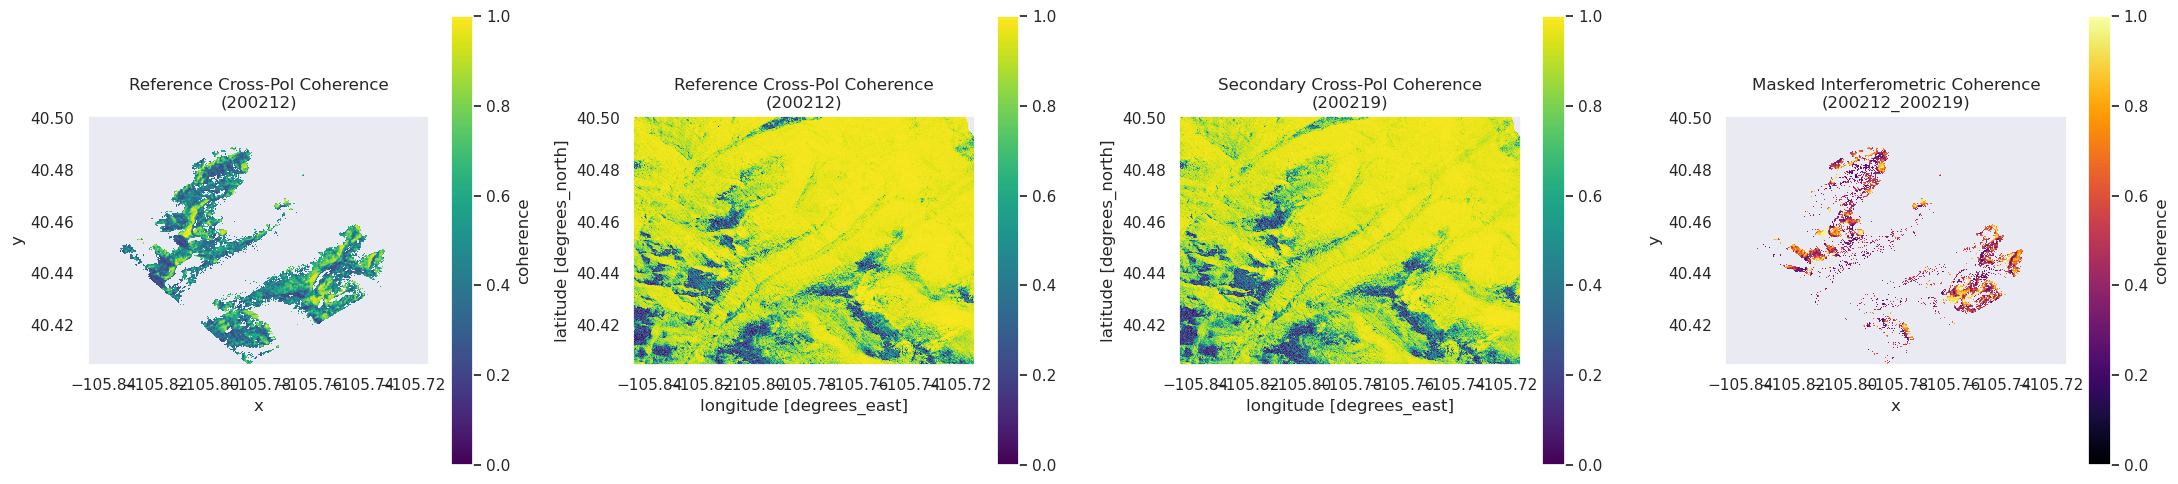

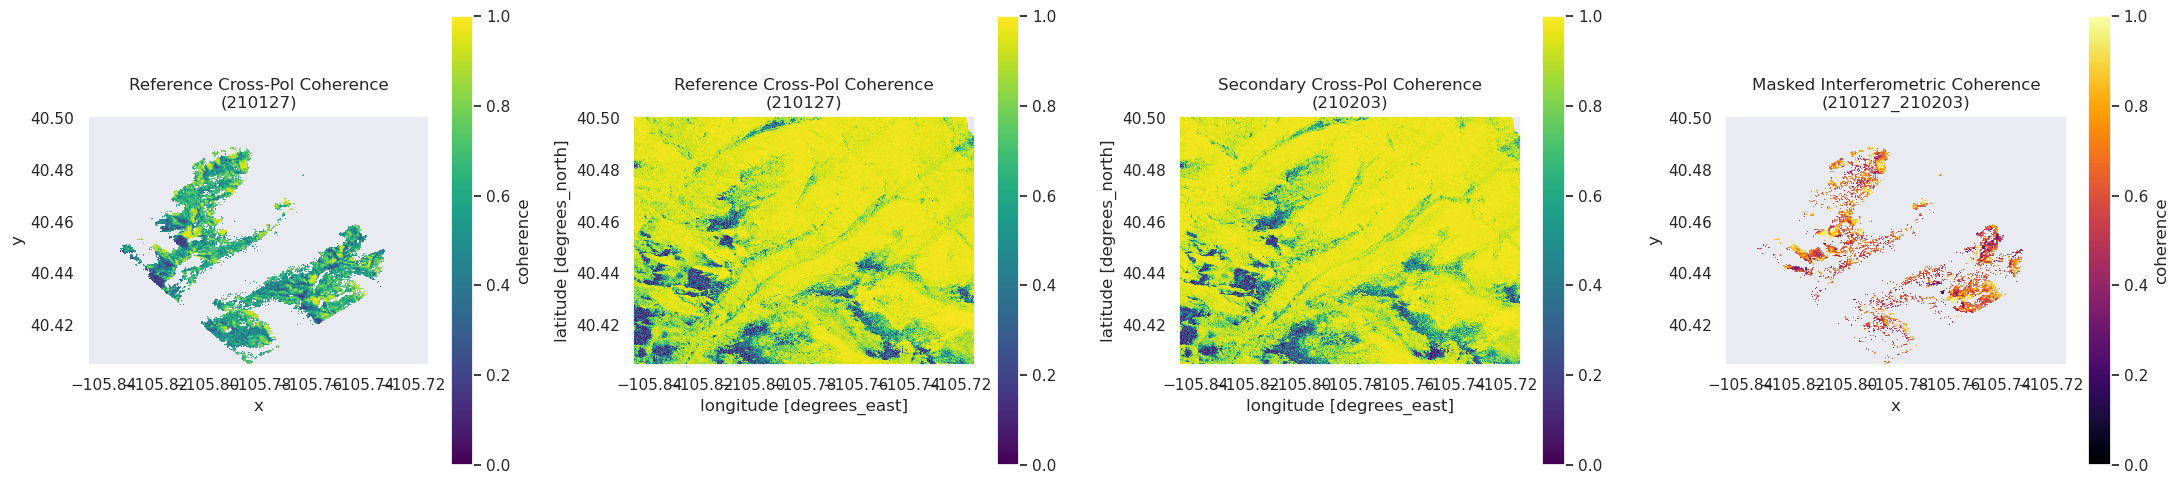

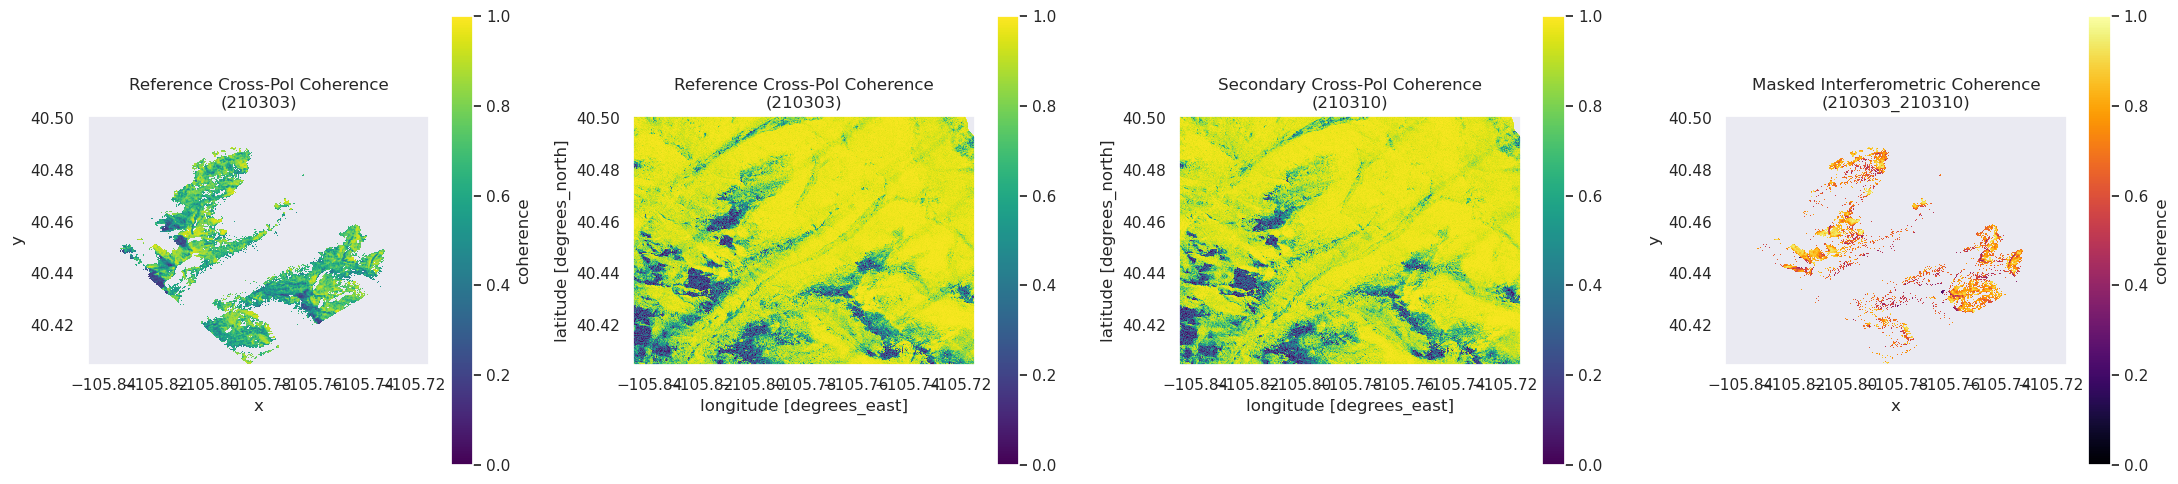

/tmp/ipykernel_98641/1166109848.py:104: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  return xr.concat(filtered_subsets, dim='pair')


In [63]:
coh_dir: Path = Path(f"{data_dir}/uavsar_cohs/rockmt/32109/")
rmnp_filtered = filter_and_plot_pairs(rmnp_good, coh_dir, xpol_cutoff)

Reprojecting cross-pol datacube for 9 unique flights...


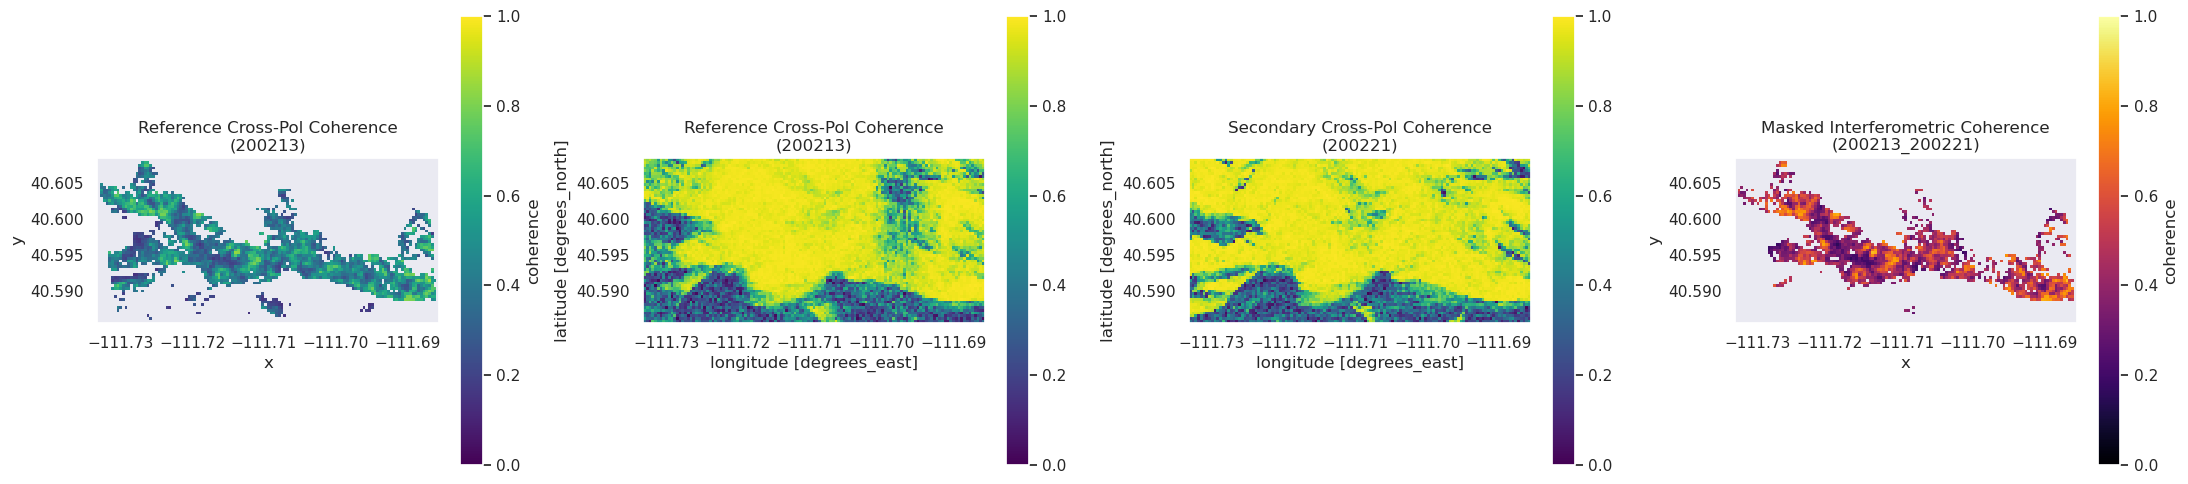

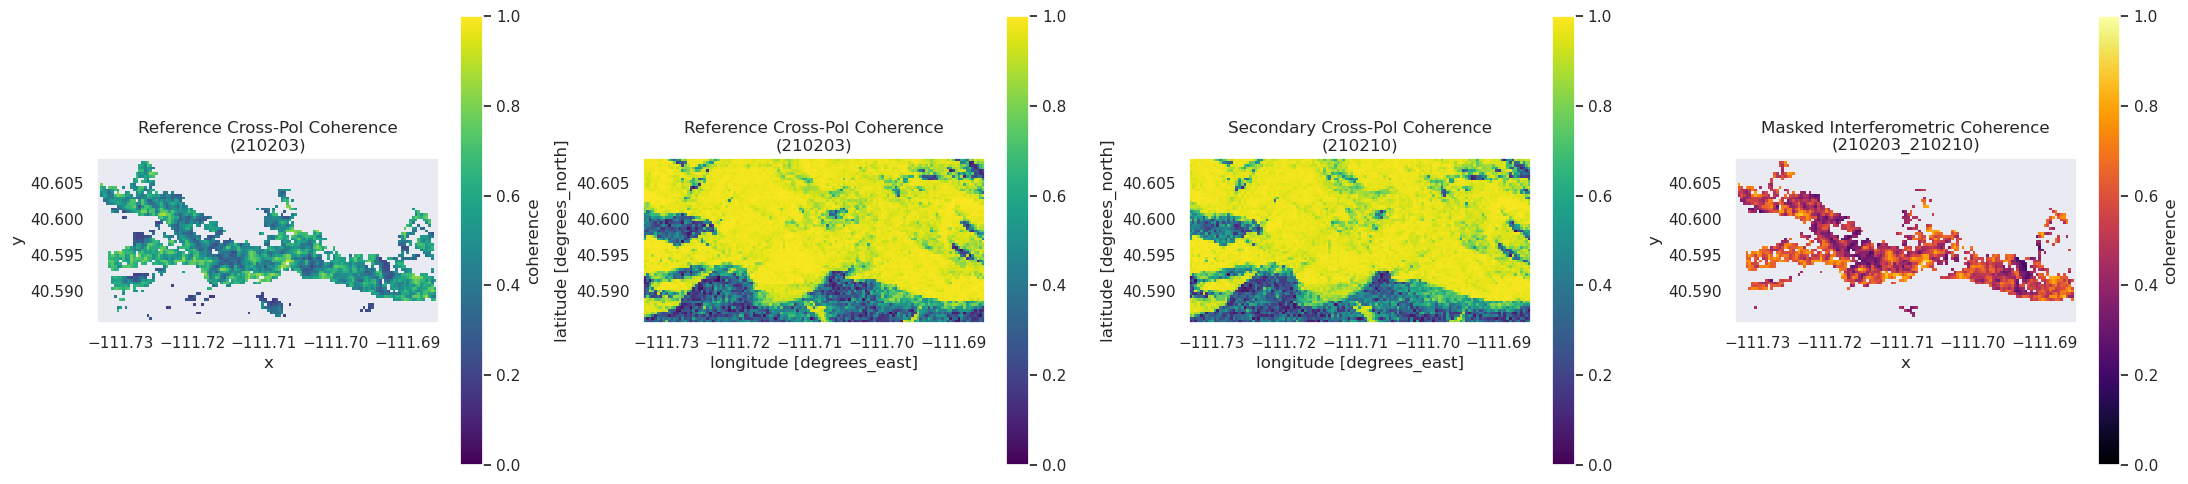

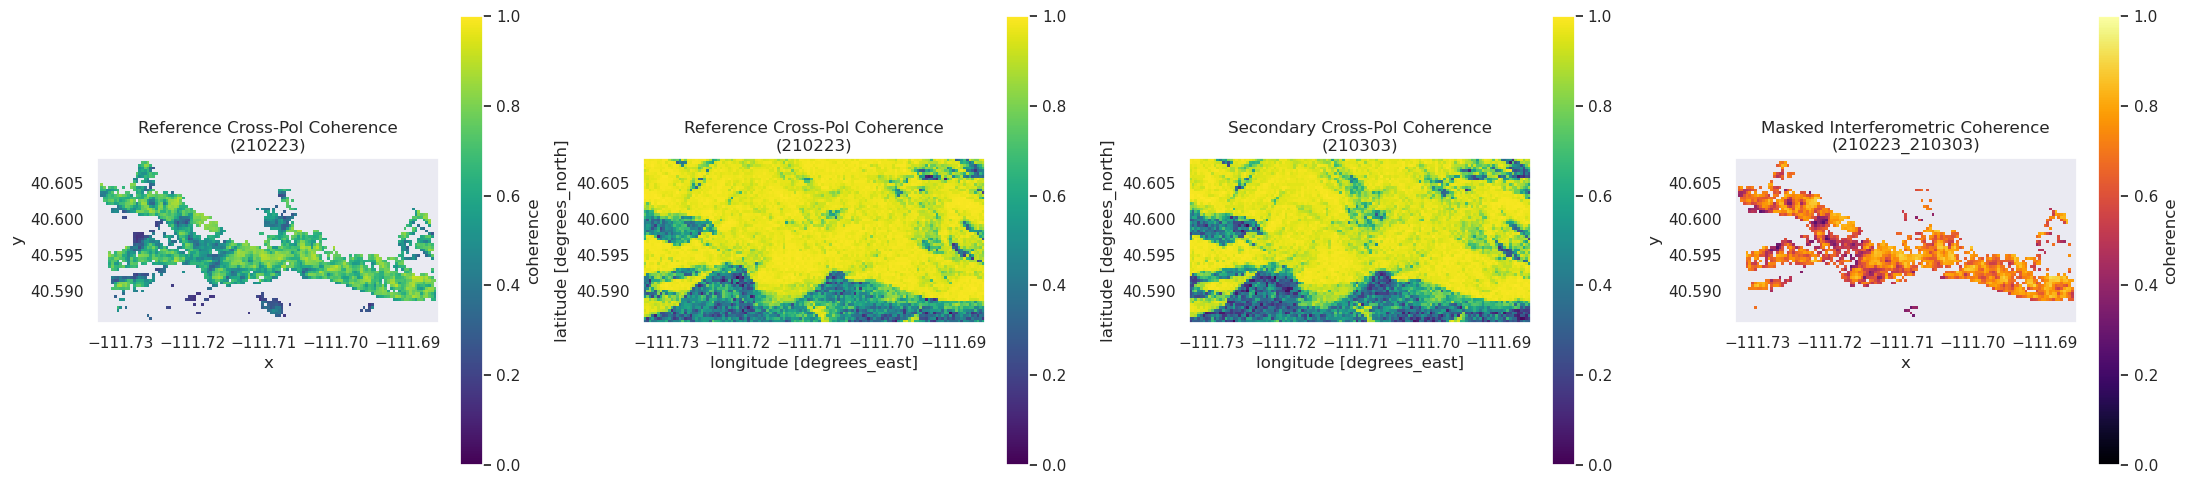

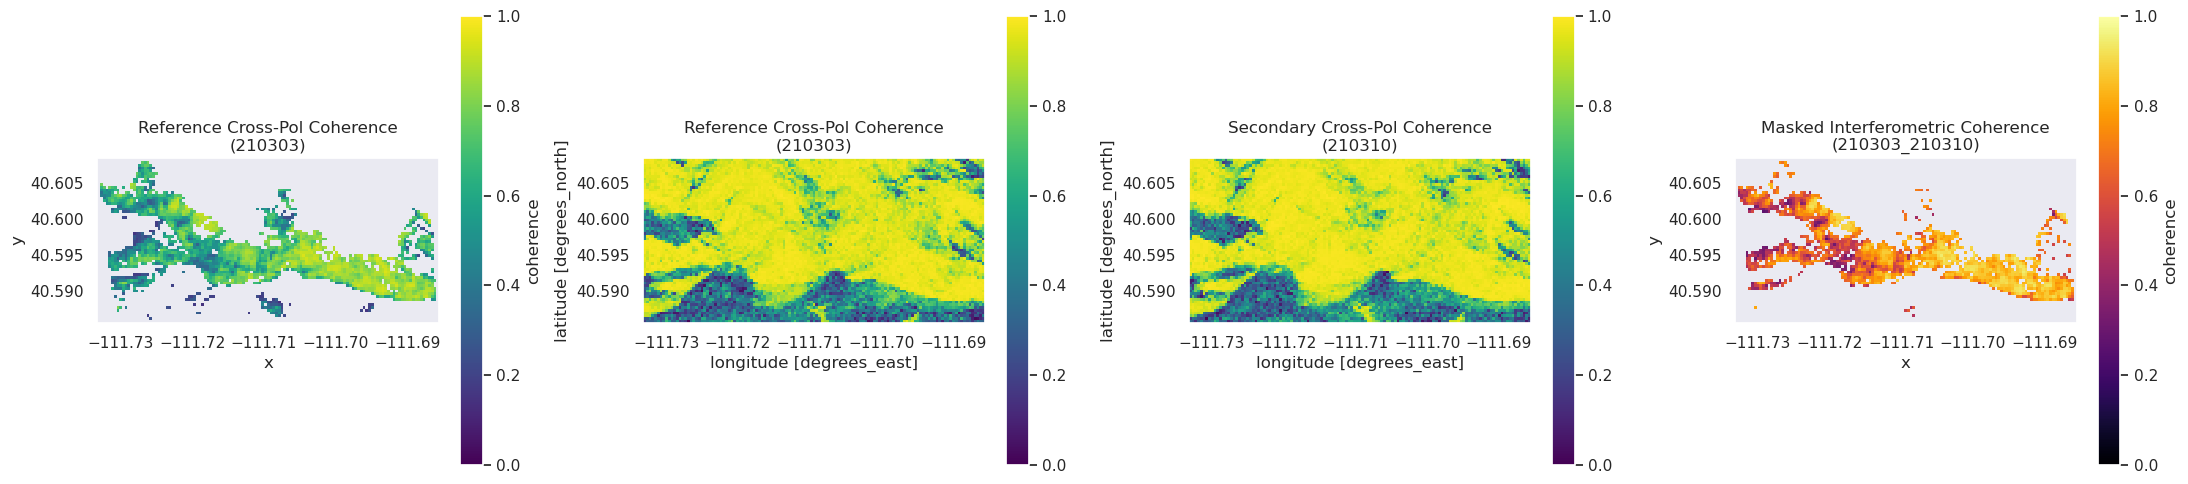

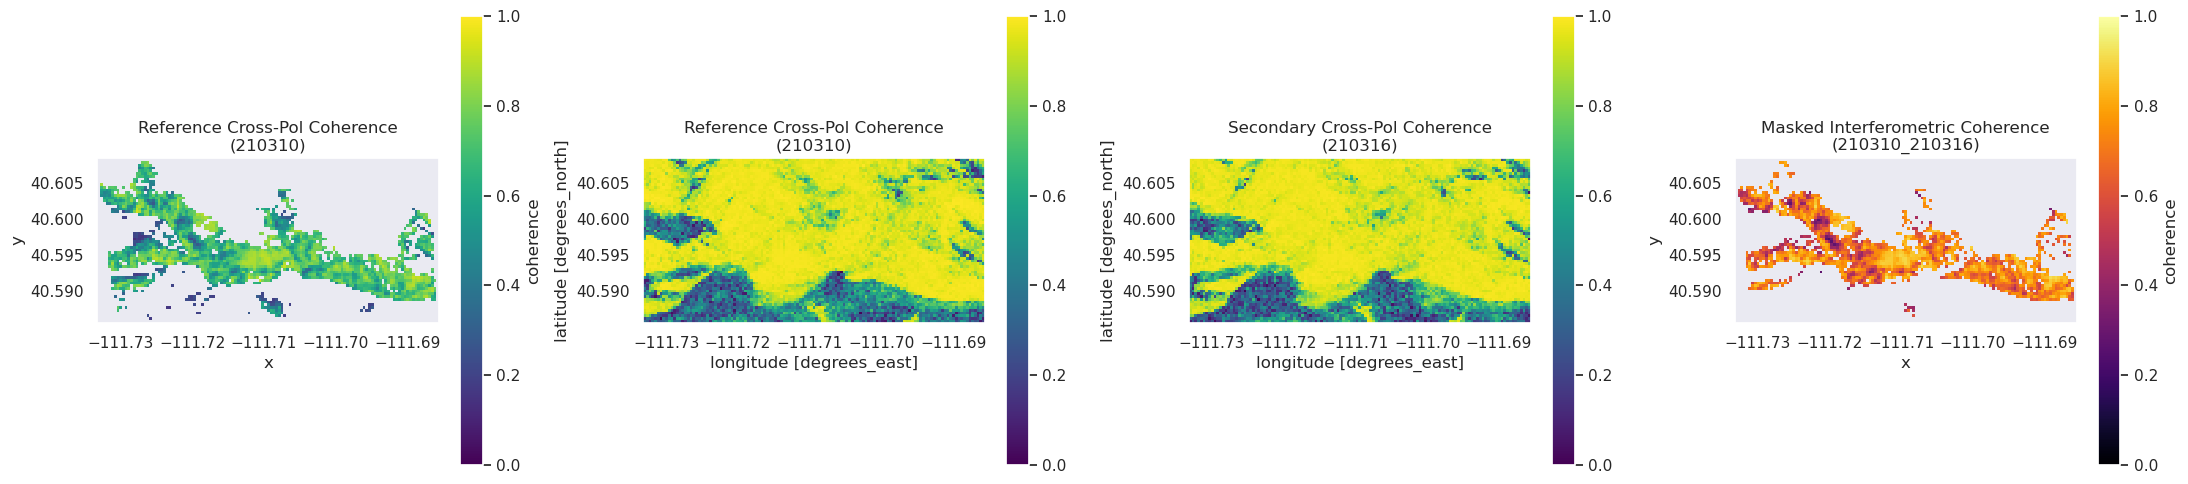

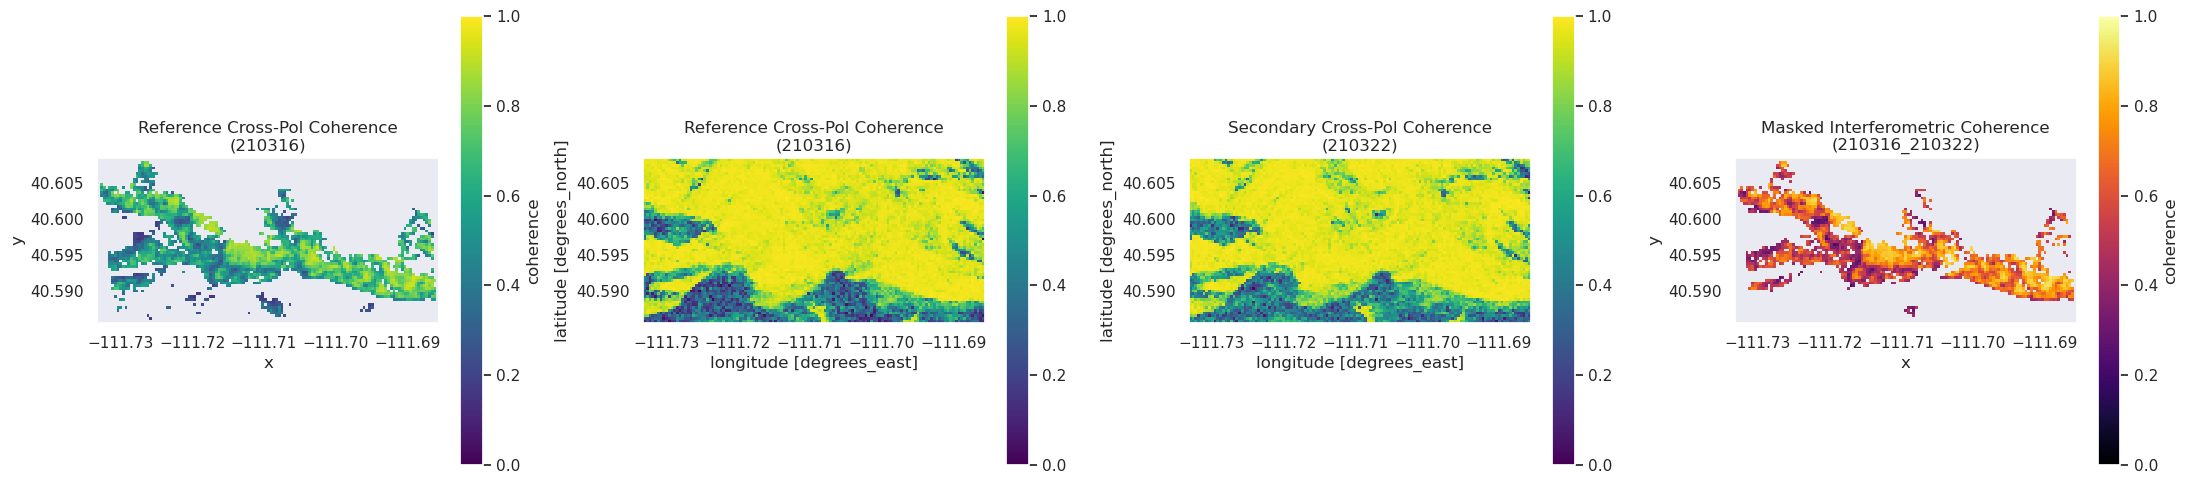

/tmp/ipykernel_98641/1166109848.py:104: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  return xr.concat(filtered_subsets, dim='pair')


In [64]:
coh_dir: Path = Path(f"{data_dir}/uavsar_cohs/stlake/27129/")
slc_filtered = filter_and_plot_pairs(slc_good, coh_dir, xpol_cutoff)

In [92]:
rmnp_array = rmnp_filtered.to_array(dim='variable')
rmnp_array_flat = rmnp_array.values.reshape(rmnp_array.shape[0], -1).T
rmnp_df = pd.DataFrame(rmnp_array_flat, 
                       columns=[v for v in rmnp_filtered.data_vars])
# rmnp_df

,acq_day_precip,avg_precip,avg_rain,avg_snow,canopy_2019,coherence,cover_2019,elevation,incidence_angle,max_temp,max_wind,mean_temp,mean_wind,snow_status_change,swe_ablate,swe_accum,total_precip,total_rain,total_snow,temp_baseline
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265171,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
265172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
265173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
265174,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
slc_array = slc_filtered.to_array(dim='variable')
slc_array_flat = slc_array.values.reshape(slc_array.shape[0], -1).T
slc_df = pd.DataFrame(slc_array_flat, 
                           columns=[v for v in slc_filtered.data_vars])
# slc_df

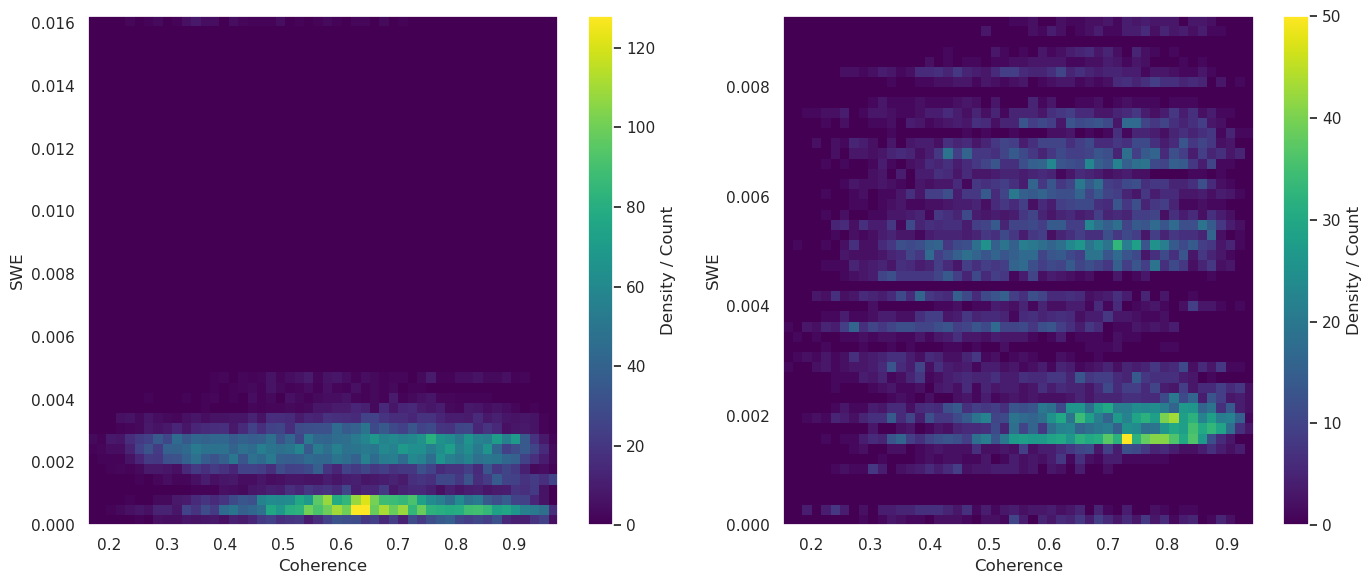

In [68]:
rmnp_clean = rmnp_df[['coherence', 'swe_accum']].dropna()

# 2. Clean slc_df similarly
slc_clean = slc_df[['coherence', 'swe_accum']].dropna()

# Quick sanity check: Ensure we actually have data left to plot
if rmnp_clean.empty or slc_clean.empty:
    raise ValueError("One of the DataFrames is completely empty after dropping NaNs! Check your data loading step.")

# 3. Plot using the cleaned data
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap for rmnp_df
h1 = axes[0].hist2d(
    rmnp_clean['coherence'], 
    rmnp_clean['swe_accum'], 
    bins=50, 
    cmap='viridis'
)
axes[0].set_ylabel('SWE')
axes[0].set_xlabel('Coherence')
fig.colorbar(h1[3], ax=axes[0], label='Density / Count')

# Heatmap for slc_df
h2 = axes[1].hist2d(
    slc_clean['coherence'], 
    slc_clean['swe_accum'], 
    bins=50, 
    cmap='viridis'
)
axes[1].set_ylabel('SWE')
axes[1].set_xlabel('Coherence')
fig.colorbar(h2[3], ax=axes[1], label='Density / Count')

plt.tight_layout()
plt.show()

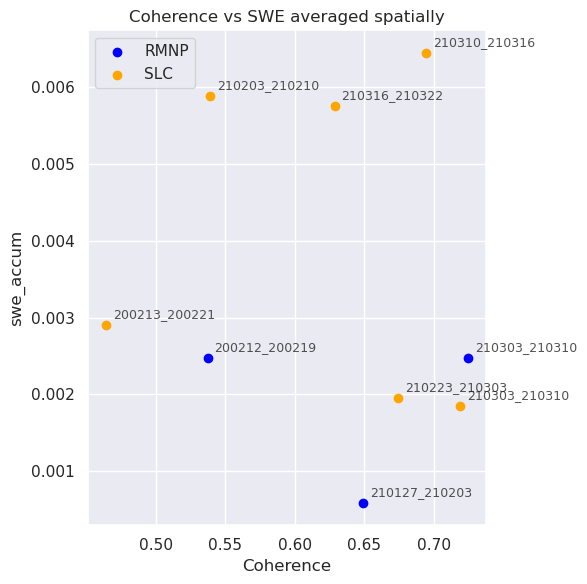

In [109]:
var_name = 'swe_accum'
# var_name = 'total_snow'

fig, axes = plt.subplots(1, 1, figsize=(6, 6))

rmnp_x = rmnp_filtered['coherence'].mean(dim=['x', 'y'])
rmnp_y = rmnp_filtered[var_name].mean(dim=['x', 'y'])

axes.scatter(rmnp_x.values, rmnp_y.values, color='blue', label='RMNP')
axes.set_ylabel(f'{var_name}')
axes.set_xlabel('Coherence')
axes.set_title('Coherence vs SWE averaged spatially')

# Loop through the pairs and annotate
for p in rmnp_filtered['pair'].values:
    x_val = rmnp_x.sel(pair=p).compute().item()
    y_val = rmnp_y.sel(pair=p).compute().item()
    
    axes.annotate(
        text=str(p),             # The text label (pair name)
        xy=(x_val, y_val),       # Point to label
        xytext=(5, 5),           # Offset text by 5 points north-east
        textcoords="offset points", 
        fontsize=9,
        alpha=0.8
    )

# --- Plot 2: SLC ---
# Calculate the means (keeps the 'pair' dimension)
slc_x = slc_filtered['coherence'].mean(dim=['x', 'y'])
slc_y = slc_filtered[var_name].mean(dim=['x', 'y'])

axes.scatter(slc_x.values, slc_y.values, color='orange', label='SLC')

# Loop through the pairs and annotate
for p in slc_filtered['pair'].values:
    x_val = slc_x.sel(pair=p).compute().item()
    y_val = slc_y.sel(pair=p).compute().item()
    
    axes.annotate(
        text=str(p), 
        xy=(x_val, y_val), 
        xytext=(5, 5), 
        textcoords="offset points", 
        fontsize=9,
        alpha=0.8
    )

axes.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [85]:
def map_swe_and_coherence(
    dataset, 
    var_name='swe_accum',
): 
    pair_names = dataset['pair'].values

    for i, p in enumerate(pair_names): 
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes = axes.flatten()

        to_plot = dataset.sel(pair=[p])

        to_plot['coherence'].plot(ax=axes[0], cmap='plasma', vmin=0, vmax=1, cbar_kwargs={'shrink': 0.7})
        to_plot[var_name].plot(ax=axes[1], cmap='Blues', cbar_kwargs={'shrink': 0.7})

        axes[0].set_title(f"Average Coherence: {to_plot['coherence'].mean().values:.5f}")
        axes[1].set_title(f"Average {var_name}: {to_plot[var_name].mean().values:.5f}")

        axes[0].set_aspect('equal')
        axes[1].set_aspect('equal')

        axes[0].tick_params(axis='x', labelrotation=45)
        axes[1].tick_params(axis='x', labelrotation=45)

        fig.suptitle(f'Pair: {p}')

        plt.tight_layout()
        plt.show()

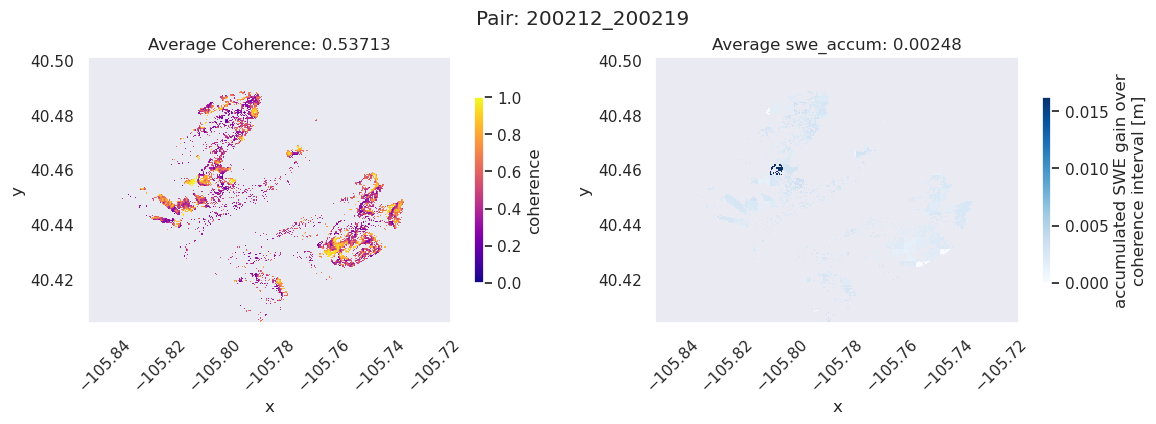

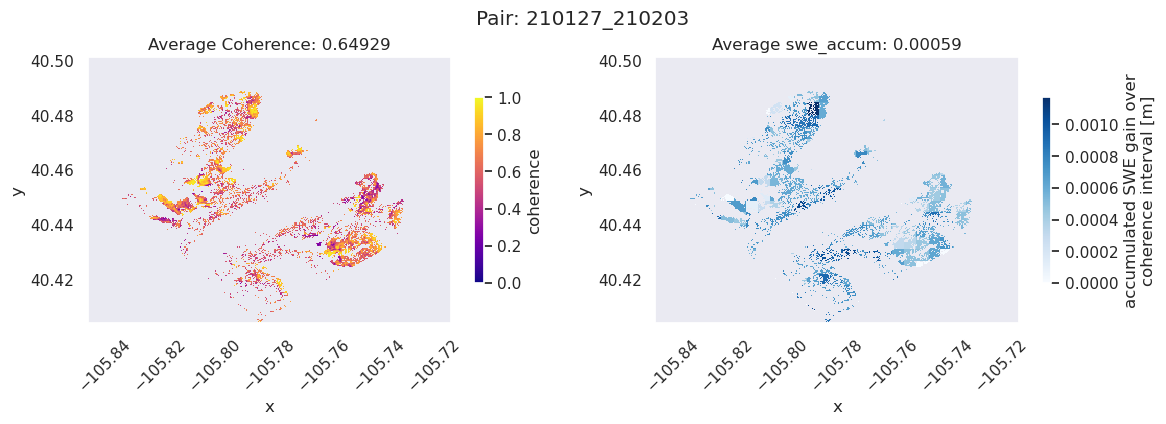

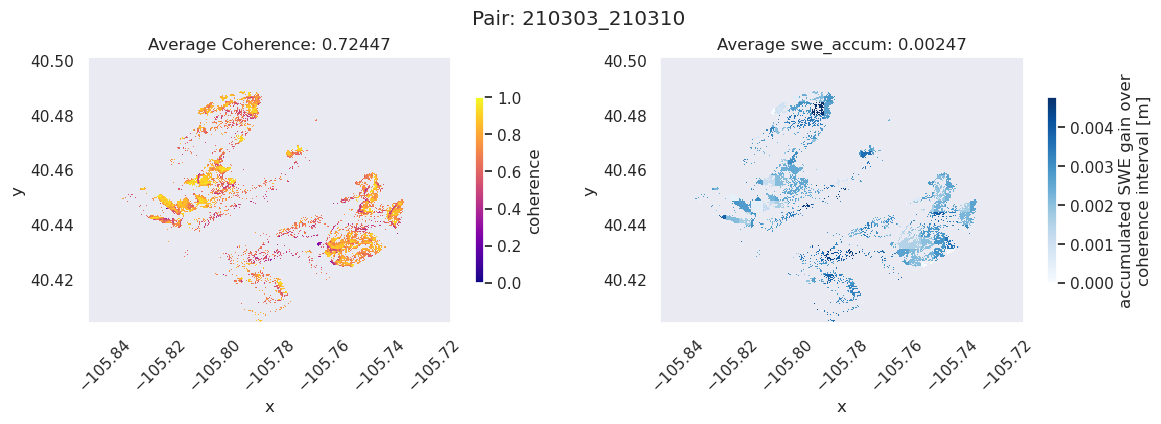

In [86]:
map_swe_and_coherence(rmnp_filtered, 
                      var_name='swe_accum')

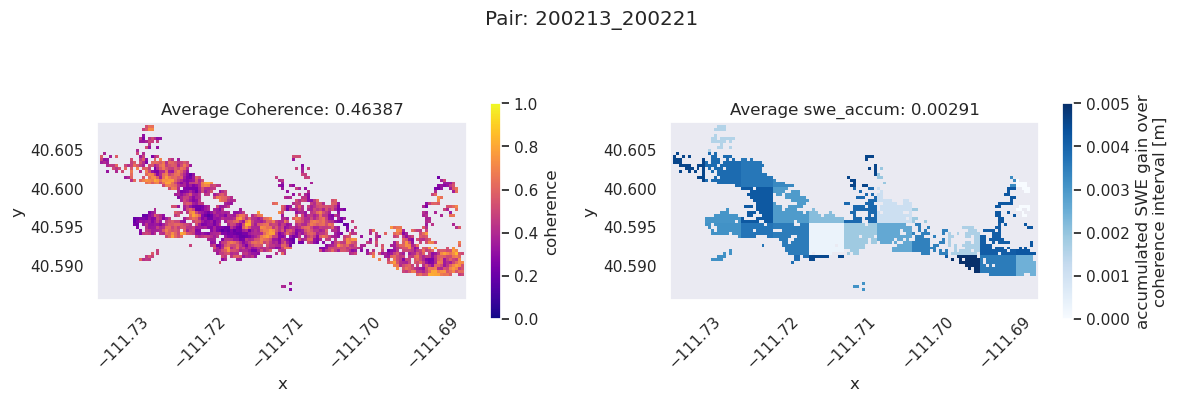

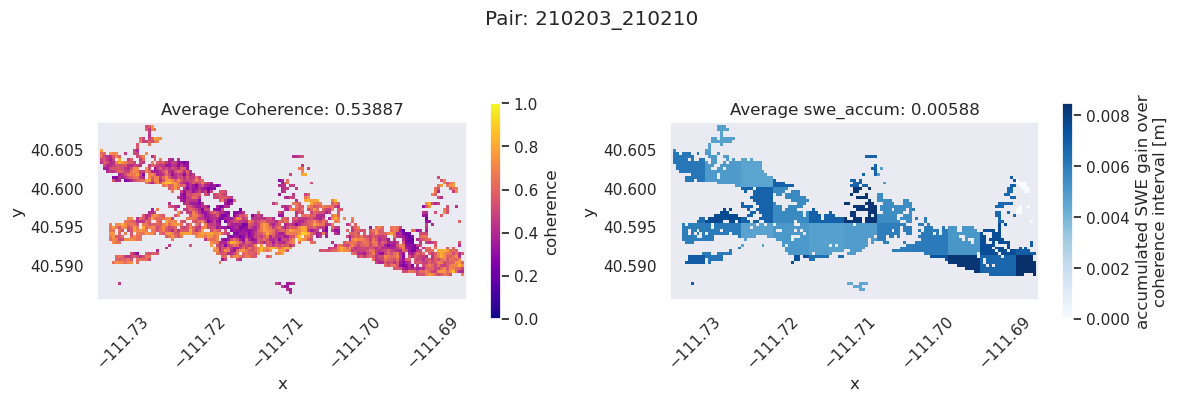

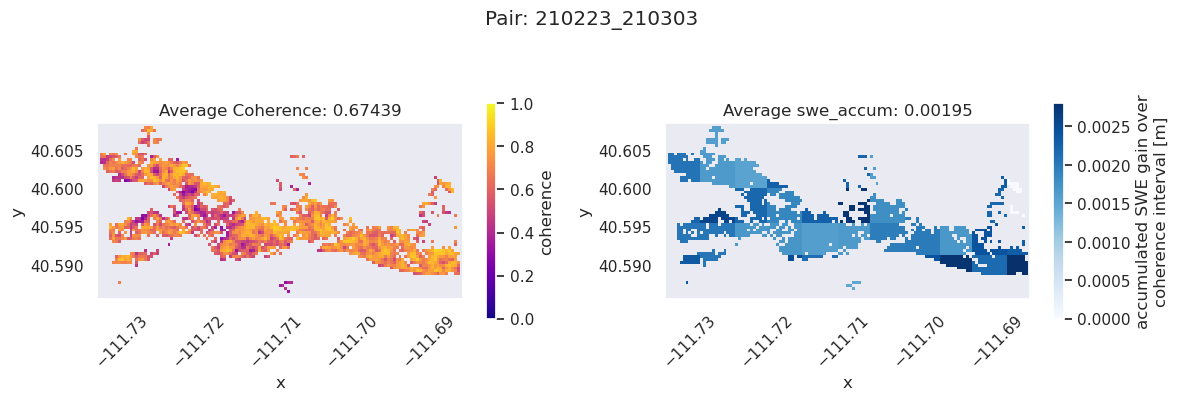

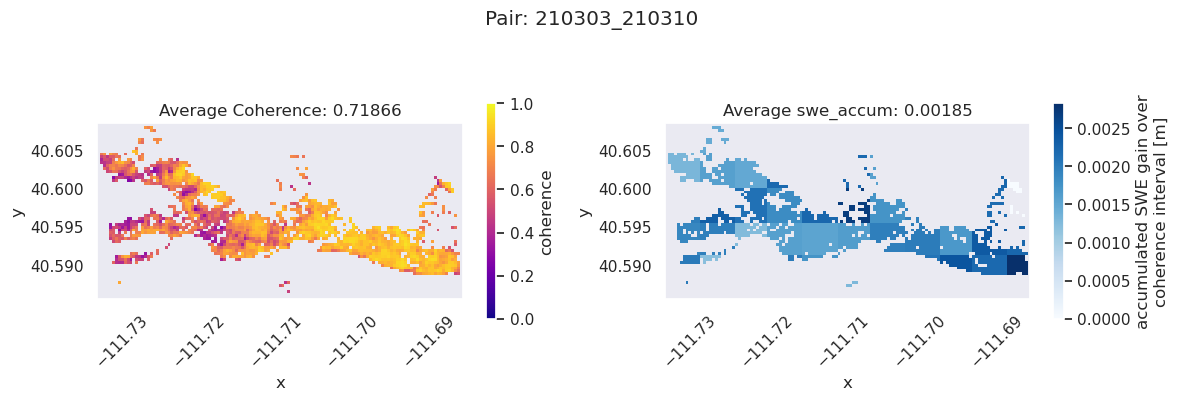

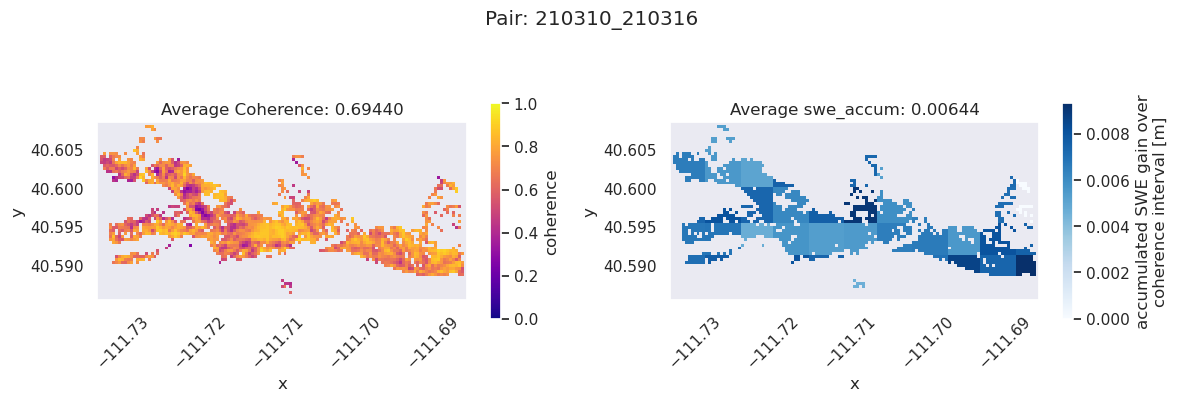

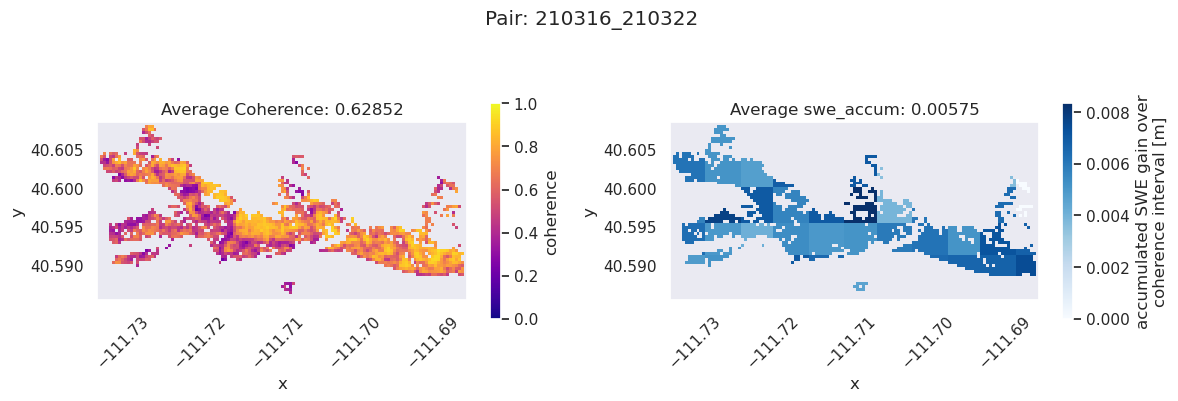

In [87]:
map_swe_and_coherence(slc_filtered, 
                      var_name='swe_accum')